In [ ]:
#1️⃣ Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

   Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  CoarseAggregate  \
0   540.0               0.0     0.0  162.0               2.5           1040.0   
1   540.0               0.0     0.0  162.0               2.5           1055.0   
2   332.5             142.5     0.0  228.0               0.0            932.0   
3   332.5             142.5     0.0  228.0               0.0            932.0   
4   198.6             132.4     0.0  192.0               0.0            978.4   

   FineAggregate  Age  CompressiveStrength  
0          676.0   28                79.99  
1          676.0   28                61.89  
2          594.0  270                40.27  
3          594.0  365                41.05  
4          825.5  360                44.30  
Cement                 0
BlastFurnaceSlag       0
FlyAsh                 0
Water                  0
Superplasticizer       0
CoarseAggregate        0
FineAggregate          0
Age                    0
CompressiveStrength    0
dtype: int64


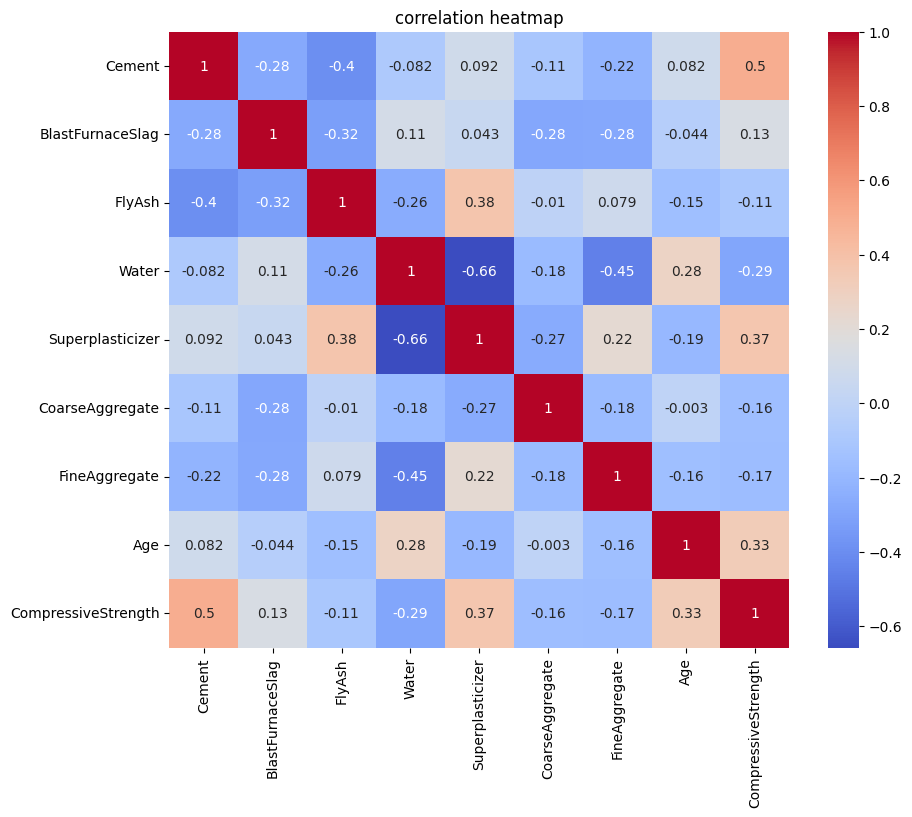

In [ ]:
#2️⃣ Load & Inspect Data

df=pd.read_csv("concrete.csv")
print(df.head())
print(df.isnull().sum())

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True ,cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()
target="CompressiveStrength"

In [10]:
#3️⃣ Handle Missing Values & Outliers
## Fill missing values
for col in df.columns:
    if df[col].dtypes=='object':
        df[col]=df[col].fillna((df[col].mode()[0]))
    else:
        df[col]=df[col].fillna(df[col].median())

# Remove outliers using IQR
for col in df.select_dtypes(include=np.number).columns:
    if col!=target:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR
        df[col]=np.where((df[col]<lower)|(df[col]>upper),df[col].median(),df[col])


In [16]:
#4️⃣ Split Data
x=df.drop(target,axis=1)
y=df[target]
x_test,x_train,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [14]:
#5️⃣ Scale Features
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [20]:
#6️⃣ Train & Evaluate Model
model=LinearRegression()
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 81.29228753641365
RMSE: 9.016223574003345
MAE: 7.0504971433646535
R²: 0.6845185217817525


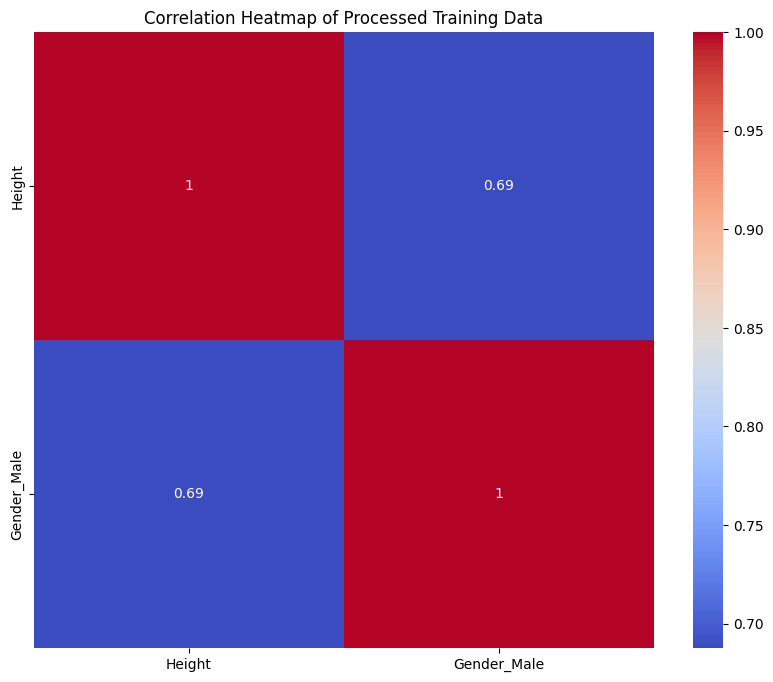


🤖 Training the regression model...
✅ Model training complete!

--- Regression Metrics on Test Set --- 📈
Mean Squared Error (MSE): 104.74
Root Mean Squared Error (RMSE): 10.23
Mean Absolute Error (MAE): 8.00
R-squared (R²): 0.9000


In [5]:
# === 1. IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === 2. LOAD DATASET ===
df = pd.read_csv("weight-height.csv")
target = "Weight" # The name of our target column

# Handle the 'Gender' column having string values
if 'Gender' in df.columns:
    df = pd.get_dummies(df, columns=['Gender'], drop_first=True)


# === 3. DEFINE FEATURES (X) AND TARGET (y), THEN SPLIT FIRST ===
# This is the most important step to prevent data leakage.
X = df.drop(target, axis=1) # Use the 'target' variable
y = df[target]                # Use the 'target' variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# === 4. DATA CLEANING & PREPROCESSING (LEARN FROM TRAIN, APPLY TO BOTH) ===
# Note: The weight-height dataset is clean, but this is the correct workflow.

# Impute missing values (if any)
for col in X_train.columns:
    # Learn median from the training data only
    median_val = X_train[col].median()
    # Apply it to fill NaNs in both train and test sets
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Handle outliers (if any)
for col in X_train.select_dtypes(include=np.number).columns:
    # Learn quantiles and bounds from the training data only
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Learn the median for replacement from the training data
    replacement_median = X_train[col].median()

    # Apply the learned bounds and replacement value to both sets
    # Note the corrected syntax with parentheses and median()
    X_train[col] = np.where((X_train[col] < lower_bound) | (X_train[col] > upper_bound), replacement_median, X_train[col])
    X_test[col] = np.where((X_test[col] < lower_bound) | (X_test[col] > upper_bound), replacement_median, X_test[col])


# === 5. FEATURE SCALING ===
# There are no categorical features left in this dataset after get_dummies,
# so we can proceed directly to scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# === 6. EDA (Optional): Correlation Heatmap on Cleaned Training Data ===
# It's best practice to do EDA on the processed training data.
temp_df_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
plt.figure(figsize=(10, 8))
sns.heatmap(temp_df_train.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Processed Training Data")
plt.show()


# === 7. TRAIN THE MODEL ===
print("\n🤖 Training the regression model...")
model = Ridge(random_state=42)
model.fit(X_train_scaled, y_train)
print("✅ Model training complete!")


# === 8. MAKE PREDICTIONS AND EVALUATE ===
y_pred = model.predict(X_test_scaled)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Regression Metrics on Test Set --- 📈")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

The 5 Core Steps
Load 📂
Get your data into a DataFrame.

Code: df = pd.read_csv("your_data.csv")

Split ✂️
Create separate training and testing sets. Do this immediately after loading.

Code: X_train, X_test, ... = train_test_split(X, y)

Process 🔧
Clean, encode, and scale the data. Learn the rules from X_train only and apply them to both sets.

Code: Use .fillna(), pd.get_dummies(), and StandardScaler().

Train 🏋️
Fit the model to your processed training data.

Code: model.fit(X_train_scaled, y_train)

Evaluate ✅
Make predictions on the unseen test set and score the model's performance.

Code: y_pred = model.predict(X_test_scaled), accuracy_score(y_test, y_pred)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# === 1. LOAD DATA ===
# Let's assume 'your_mixed_dataset.csv' has both number and text columns
# df = pd.read_csv("your_mixed_dataset.csv")
# For demonstration, we'll create one:
df=pd.read_csv("weight-height.csv")
target="Weight"
# === 2. SPLIT DATA FIRST TO PREVENT LEAKAGE ===
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# === 3. DATA CLEANING & PREPROCESSING (LEARN FROM TRAIN, APPLY TO BOTH) ===
# Impute missing values
#3️⃣ Handle Missing Values & Outliers
## Fill missing values
for col in df.columns:
    if df[col].dtypes=='object':
        df[col]=df[col].fillna((df[col].mode()[0]))
    else:
        df[col]=df[col].fillna(df[col].median())

# Remove outliers using IQR
for col in df.select_dtypes(include=np.number).columns:
    if col!=target:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR
        df[col]=np.where((df[col]<lower)|(df[col]>upper),df[col].median(),df[col])


# === 4. ENCODE CATEGORICAL FEATURES USING get_dummies() ===
# This is the step you asked to add.
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align columns to ensure train and test sets match
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded,join="left" axis=1, fill_value=0)


# === 5. SCALE THE FEATURES ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)


# === 6. TRAIN THE MODEL ===
model = LinearRegression()
model.fit(X_train_scaled, y_train)


# === 7. MAKE PREDICTIONS AND EVALUATE ===
y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 101.24427647013302
RMSE: 10.062021490244046
MAE: 7.962168764049688
R²: 0.9033321846361925
